<a href="https://colab.research.google.com/github/kadiwala1234/unsupervised-learning-project/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Assignment 9: Unsupervised Learning**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Load Dataset
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)

In [3]:
# Preprocessing
# Check missing values
print(df.isnull().sum())

# Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


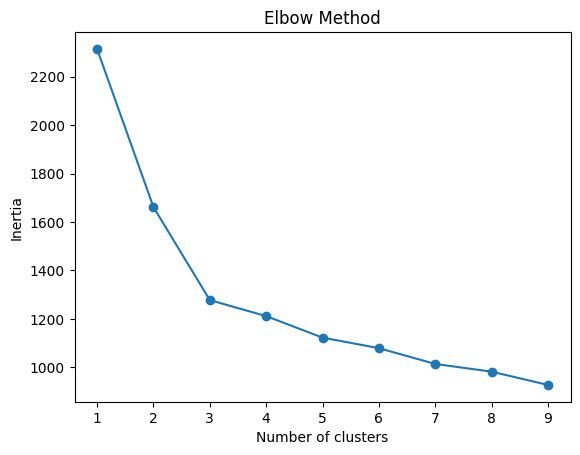

In [4]:
# K-Means Clustering
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Elbow Plot
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [5]:
# Fit Optimal K (e.g., k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(scaled_data)

print("Silhouette Score:", silhouette_score(scaled_data, labels_kmeans))

Silhouette Score: 0.2848589191898987


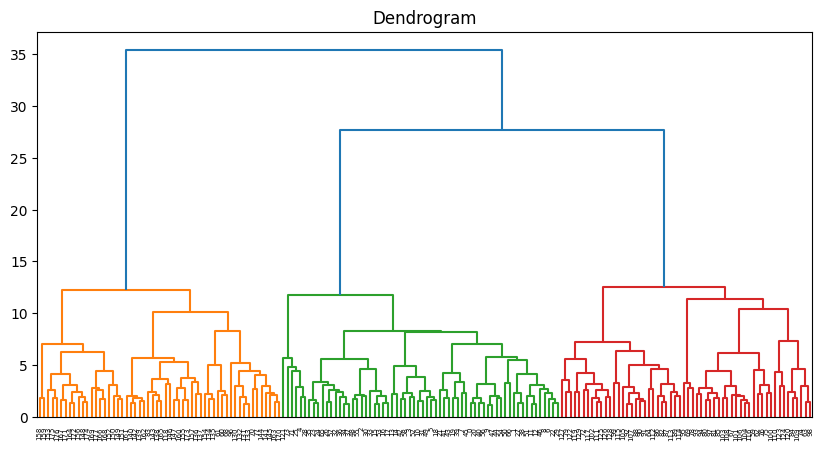

In [6]:
# Hierarchical Clustering
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

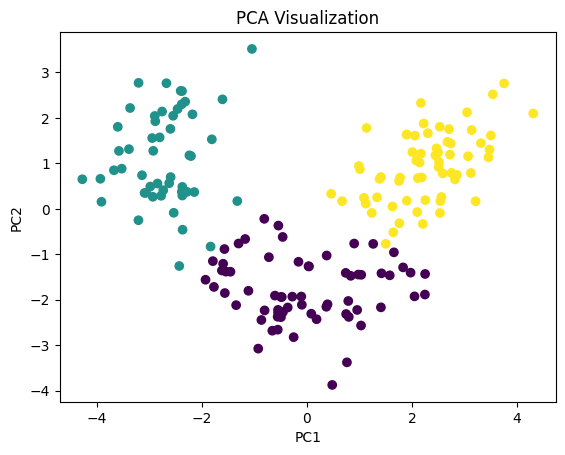

In [7]:
# PCA (Dimensionality Reduction)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_kmeans, cmap='viridis')
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()